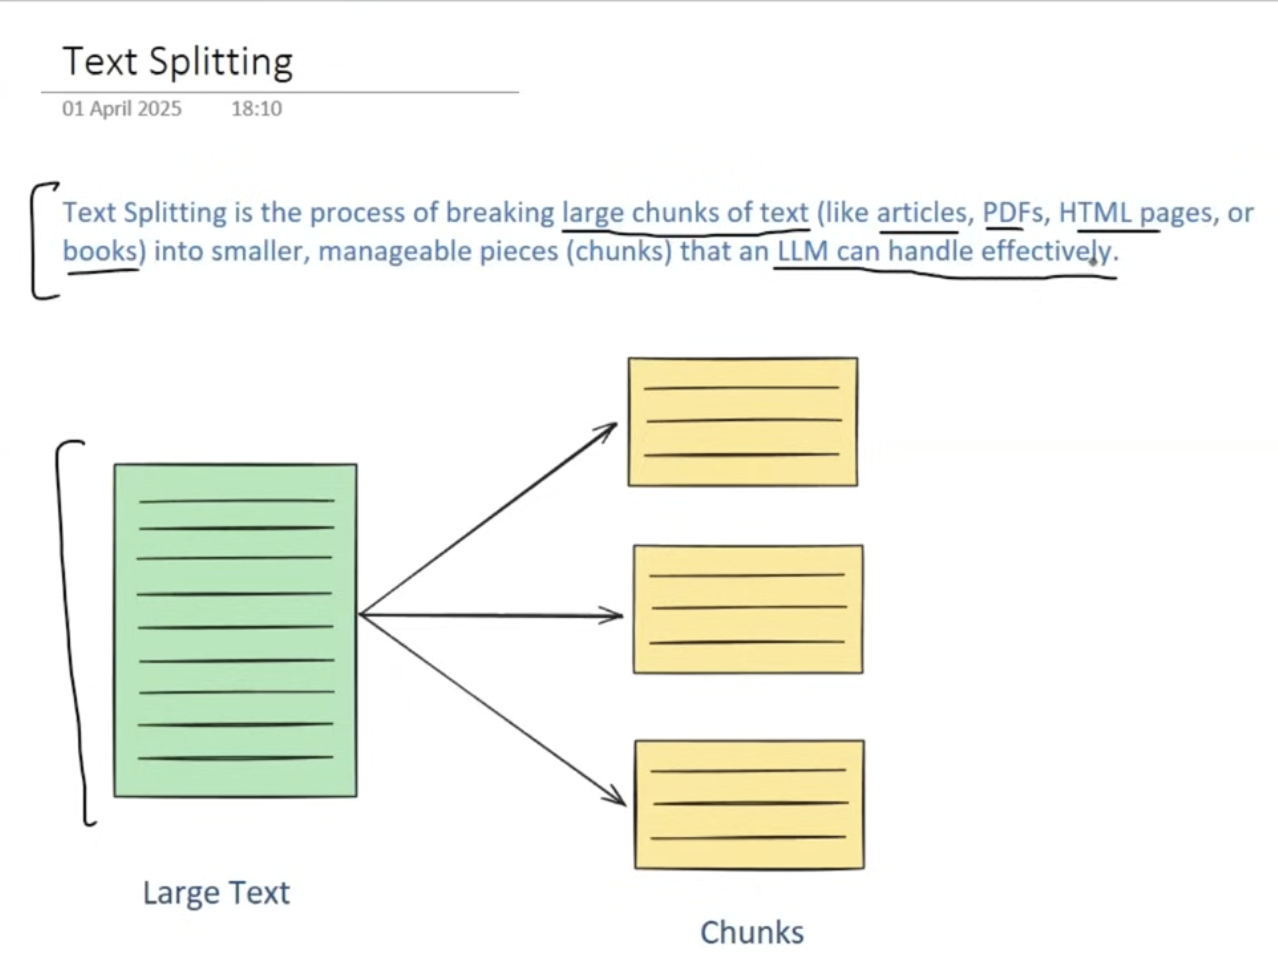

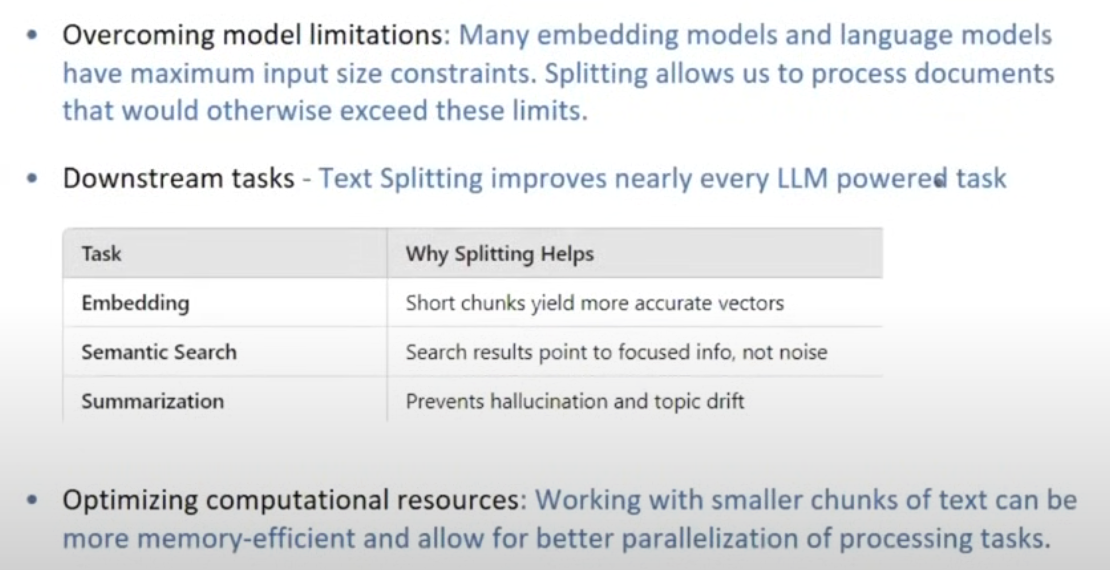

<h1 style="color:rgb(255, 98, 0);">1. Length Based Text Splitting</h1>

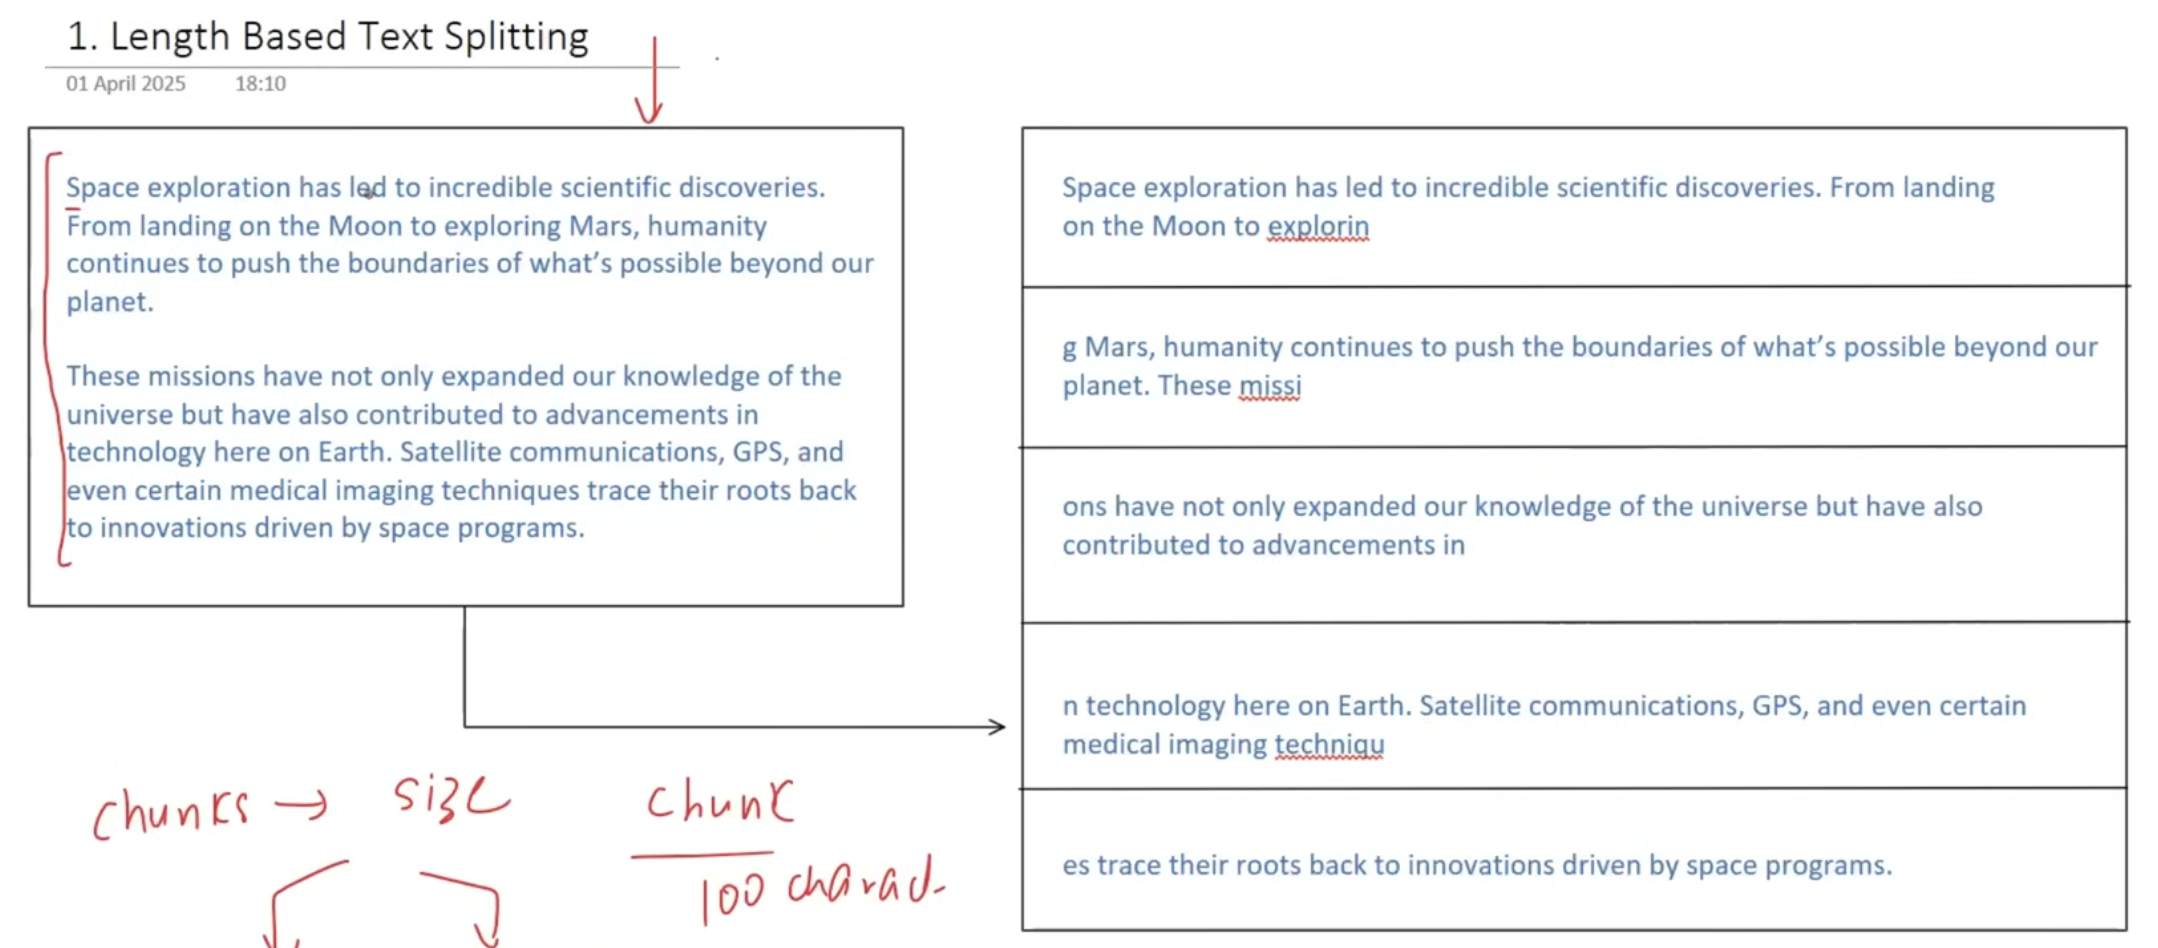

In [2]:
from langchain.text_splitter import CharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader('Types Of RAG.pdf')

docs = loader.load()

splitter = CharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=0,
    separator=''
)

result = splitter.split_documents(docs)

print(result[1].page_content)

1. Standard RAG
Combines retrieval with large
language models for accurate,
context-aware responses.
Breaks documents into chunks for
efficient information retrieval.
Aims for 1-2 second response time


<h1 style="color:rgb(255, 98, 0);">2. Text Structure Based Text Splitting</h1>

| Symbol         | Meaning / Usage                                               | Example in Text                        |
|----------------|---------------------------------------------------------------|----------------------------------------|
| `#`, `##`, etc.| Markdown headers (used to split by section level)             | `## Introduction`                      |
| `\n\n`         | Paragraph separator (double newline)                          | `"This is para 1.\n\nThis is para 2."` |
| `-`            | Bullet point or list separator                                | `- Item 1`                             |
| `*`            | Bullet point (Markdown or emphasis)                           | `* Item 2`                             |
| `>`            | Blockquote separator                                          | `> Quoted text`                        |
| `---` or `***` | Horizontal rule (indicates section breaks)                    | `---`                                  |
| `###`          | Subheading (used in `MarkdownHeaderTextSplitter`)             | `### Details`                          |
| `:`            | Key-value separator (used in YAML / structured formats)       | `key: value`                           |
| `[]()`         | Markdown links (used in semantic parsing or link separation)  | `[Google](https://google.com)`         |
| `**`, `__`     | Bold (may be used in emphasis-aware splits)                   | `**Important**`                        |


In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text = """
Space exploration has led to incredible scientific discoveries. From landing on the Moon to exploring Mars, humanity continues to push the boundaries of what’s possible beyond our planet.

These missions have not only expanded our knowledge of the universe but have also contributed to advancements in technology here on Earth. Satellite communications, GPS, and even certain medical imaging techniques trace their roots back to innovations driven by space programs.
"""

# Initialize the splitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
)

# Perform the split
chunks = splitter.split_text(text)

print(len(chunks))
print(chunks)

4
['Space exploration has led to incredible scientific discoveries. From landing on the Moon to exploring Mars, humanity continues to push the boundaries', 'of what’s possible beyond our planet.', 'These missions have not only expanded our knowledge of the universe but have also contributed to advancements in technology here on Earth. Satellite', 'communications, GPS, and even certain medical imaging techniques trace their roots back to innovations driven by space programs.']


<h1 style="color:rgb(255, 98, 0);">3. Document Structure Based Text Splitting</h1>

### Python code splitting

In [11]:
from langchain.text_splitter import RecursiveCharacterTextSplitter,Language

text = """
class Student:
    def __init__(self, name, age, grade):
        self.name = name
        self.age = age
        self.grade = grade  # Grade is a float (like 8.5 or 9.2)

    def get_details(self):
        return self.name"

    def is_passing(self):
        return self.grade >= 6.0


# Example usage
student1 = Student("Aarav", 20, 8.2)
print(student1.get_details())

if student1.is_passing():
    print("The student is passing.")
else:
    print("The student is not passing.")

"""

# Initialize the splitter
splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.PYTHON,
    chunk_size=300,
    chunk_overlap=0,
)

# Perform the split
chunks = splitter.split_text(text)

print(len(chunks))
print("Chunk 0:")
print(chunks[0])
print("\nChunk 1:")
print(chunks[1])

2
Chunk 0:
class Student:
    def __init__(self, name, age, grade):
        self.name = name
        self.age = age
        self.grade = grade  # Grade is a float (like 8.5 or 9.2)

    def get_details(self):
        return self.name"

    def is_passing(self):
        return self.grade >= 6.0

Chunk 1:
# Example usage
student1 = Student("Aarav", 20, 8.2)
print(student1.get_details())

if student1.is_passing():
    print("The student is passing.")
else:
    print("The student is not passing.")


<h1 style="color:rgb(255, 98, 0);">4. Semantic Meaning Based Text Splitting</h1>

In [38]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai.embeddings import OpenAIEmbeddings
from langchain.embeddings import HuggingFaceEmbeddings
from dotenv import load_dotenv

# load_dotenv()

embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

text_splitter = SemanticChunker(
    embedding_model,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=60  # 👈 This means: split at top 40% semantic changes
)

sample = """
Farmers were working hard in the fields, preparing the soil and planting seeds for the next season. The sun was bright, and the air smelled of earth and fresh grass. The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams.


Terrorism is a big danger to peace and safety. It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety.
"""

docs = text_splitter.create_documents([sample])

# Output the results
print(f"Chunks: {len(docs)}")
for i, doc in enumerate(docs):
    print(f"\nChunk {i+1}:\n{doc.page_content.strip()}")

Chunks: 4

Chunk 1:
Farmers were working hard in the fields, preparing the soil and planting seeds for the next season.

Chunk 2:
The sun was bright, and the air smelled of earth and fresh grass. The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams. Terrorism is a big danger to peace and safety.

Chunk 3:
It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety.

Chunk 4:



```python
2
[Document(page_content="Farmers were working hard in the fields, preparing the soil and planting seeds for the next season. The sun was bright, and the air smelled of earth and fresh grass.", metadata={}),
 Document(page_content="The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams.", metadata={}),
 Document(page_content="Terrorism is a big danger to peace and safety. It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety.", metadata={})]
